<a href="https://colab.research.google.com/github/harveenkaur282-web/ai-ml_labs/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Decision Tree Classifier for Classification**

Decision Tree Classifier is a type of supervised learning algorithm that is mostly used in classification problems. It is a tree-based model that splits the data into smaller subsets based on the features of the data. It then recursively continues this process until the data can be classified accurately. In this lab, we will be using the Iris dataset from Scikit-learn to train a Decision Tree Classifier to classify the different types of Iris flowers based on their features.

***About Dataset***

The **Iris dataset** is a well-known and commonly used dataset in machine learning and data analysis. It contains information on 150 Iris flowers, where each flower is represented by four features: sepal length, sepal width, petal length, and petal width, as well as its species (setosa, versicolor, or virginica). The dataset is included in many machine learning packages, including Scikit-learn, where it can be loaded using the load_iris() function.

**Import necessary libraries**

In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn import tree
import numpy as np

***Load the iris dataset***

In [2]:
iris = load_iris()
X = iris.data
y = iris.target

In [3]:
iris["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [4]:
data = pd.DataFrame(iris["data"], columns=iris["feature_names"])
data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


***Normalize data before training***

MinMaxScaler is used for normalization of data

In [5]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

***Split data into train and test set***

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(120, 4)
(120,)
(30, 4)
(30,)


***Train Decision tree clasifier***

In [7]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)


DecisionTreeClassifier()

***Visualize the Decision Tree***

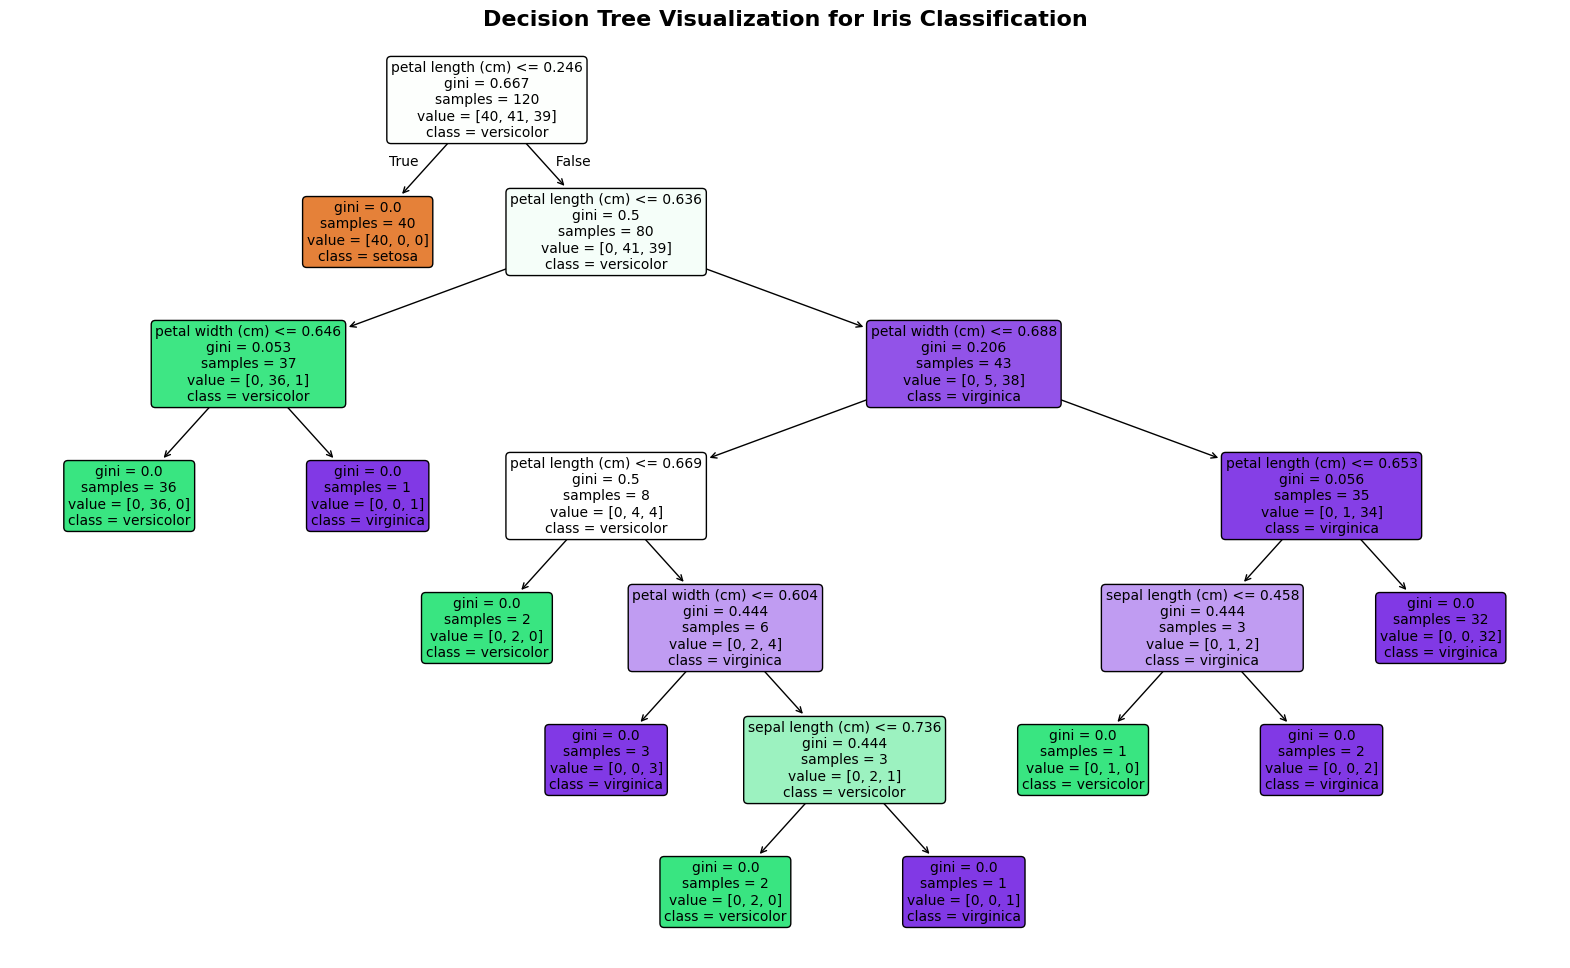

In [8]:
plt.figure(figsize=(20, 12))
plot_tree(clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Decision Tree Visualization for Iris Classification", fontsize=16, fontweight='bold')
plt.show()

***Alternative: Text-based Tree Representation***

In [9]:
tree_rules = tree.export_text(clf,
                              feature_names=iris.feature_names,
                              class_names=iris.target_names)
print("Decision Tree Rules:")
print("=" * 50)
print(tree_rules)

Decision Tree Rules:
|--- petal length (cm) <= 0.25
|   |--- class: setosa
|--- petal length (cm) >  0.25
|   |--- petal length (cm) <= 0.64
|   |   |--- petal width (cm) <= 0.65
|   |   |   |--- class: versicolor
|   |   |--- petal width (cm) >  0.65
|   |   |   |--- class: virginica
|   |--- petal length (cm) >  0.64
|   |   |--- petal width (cm) <= 0.69
|   |   |   |--- petal length (cm) <= 0.67
|   |   |   |   |--- class: versicolor
|   |   |   |--- petal length (cm) >  0.67
|   |   |   |   |--- petal width (cm) <= 0.60
|   |   |   |   |   |--- class: virginica
|   |   |   |   |--- petal width (cm) >  0.60
|   |   |   |   |   |--- sepal length (cm) <= 0.74
|   |   |   |   |   |   |--- class: versicolor
|   |   |   |   |   |--- sepal length (cm) >  0.74
|   |   |   |   |   |   |--- class: virginica
|   |   |--- petal width (cm) >  0.69
|   |   |   |--- petal length (cm) <= 0.65
|   |   |   |   |--- sepal length (cm) <= 0.46
|   |   |   |   |   |--- class: versicolor
|   |   |   |   

***Make predictions on the test data***

In [10]:
y_pred = clf.predict(X_test)

***Evaluate Model Performance***

In [11]:
con = confusion_matrix(y_test, y_pred)
print(con)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [12]:
clas = classification_report(y_test, y_pred)
print(clas)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



***Tune hyperparameters***

The performance of your machine learning model depends on the hyperparameters that you choose. Scikit-learn provides several tools to tune the hyperparameters. Here's an example of how to tune the max_depth hyperparameter of the decision tree classifier using grid search.

In [13]:
params = {'max_depth': [1, 2, 3, 4, 5]}
clf = DecisionTreeClassifier()
grid_search = GridSearchCV(clf, param_grid=params, cv=5)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)


Best parameters: {'max_depth': 4}
